In [1]:
from ultralytics import YOLO
import os
import hierarchical_yolo.yolo_utils
import hierarchical_loss.path_utils
import hierarchical_loss.viz_utils
import ultralytics
import torch
import itertools
from PIL import Image
import time
import yaml

In [2]:
# Ultralytics default settings.  See https://docs.ultralytics.com/quickstart/#ultralytics-settings
# The root directory where datasets are expected to be stored, and where ultralytics will download curated datasets
#DATASETS = ultralytics.settings['datasets_dir']
DATASETS = os.path.expanduser('~/datasets')
# The root directory for model weights.  In particular, where ultralytics will download pre-trained model .pt weight files
#WEIGHTS = ultralytics.settings['weights_dir']
WEIGHTS = os.path.expanduser('~/Models/weights')
# The root directory where training runs will be stored, including evaluation artifacts and trained model .pt weight files
#RUNS = ultralytics.settings['runs_dir']
RUNS = os.path.expanduser('~/Models/runs')

# The pre-trained model to use.  Note the v8 (version 8) and the n (nano-scale)
YOLO_BASE_WEIGHTS = os.path.join(WEIGHTS, "yolov8n.pt")

# Configure project runs save locations.
BASE_PROJECT = os.path.join(RUNS, 'gfisher')

# Find where data is downloaded/stored.  This is where ultralytics will download the coco128 data.
DATA = os.path.join(DATASETS, 'gfisher')
IMAGES_PATH = os.path.join(DATA, 'hierarchical_annotations', 'images')

# Find model configurations.  These are in the repository https://github.com/csbrown-noaa/hierarchical_yolo.
# If you aren't running this from the cloned repo, you will need to go acquire these and change MODEL_CONFIGS to reflect the location of the model config files.
MODEL_CONFIGS = '../gfisher_data_hierarchical_model/models'
YOLO_MODEL_YAML = os.path.join(MODEL_CONFIGS, 'hierarchicalgfisheryolov8.yaml')
YOLO_DATASET_YAML = os.path.join(MODEL_CONFIGS, 'hierarchical_gfisher.yaml')

In [3]:
devices = list(range(torch.cuda.device_count()))
devices = devices[0] if devices else 'cpu'

In [4]:
# Find the latest model from the last training run for this project
trained_models = os.listdir(BASE_PROJECT)
model_numbers = list(map(lambda x: int(x[len('train'):]) if len(x) > len('train') else 0, trained_models))
latest_model = 'train' + str(max(model_numbers))
latest_model

'train5'

In [5]:
# Load up the weights from the last training run in evaluation mode
trained_model = (
    YOLO(os.path.join(BASE_PROJECT, latest_model, 'weights', 'best.pt')).to(0)
)
trained_model.eval()

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [6]:
image_filenames = [filename for filename in os.listdir(IMAGES_PATH) if filename.endswith('.jpg')]

In [7]:
SAMPLE_SIZE = 1000
image_filenames = image_filenames[::max(1, int(len(image_filenames)/SAMPLE_SIZE))]
len(image_filenames)

1003

In [8]:
arbitrary_index = time.time_ns()%len(image_filenames)
arbitrary_index

68

In [9]:
# load in a test image from the training dataset.
#image_path = os.path.join(IMAGES_PATH, '000000000257.jpg')
images_path = [os.path.join(IMAGES_PATH, img) for img in image_filenames]
arbitrary_image = images_path[arbitrary_index]
arbitrary_image

'/home/noaa_brown/datasets/gfisher/hierarchical_annotations/images/SC4-camera3_03-15-21_14-35-16.000.avi.00.09.46.600000.jpg'

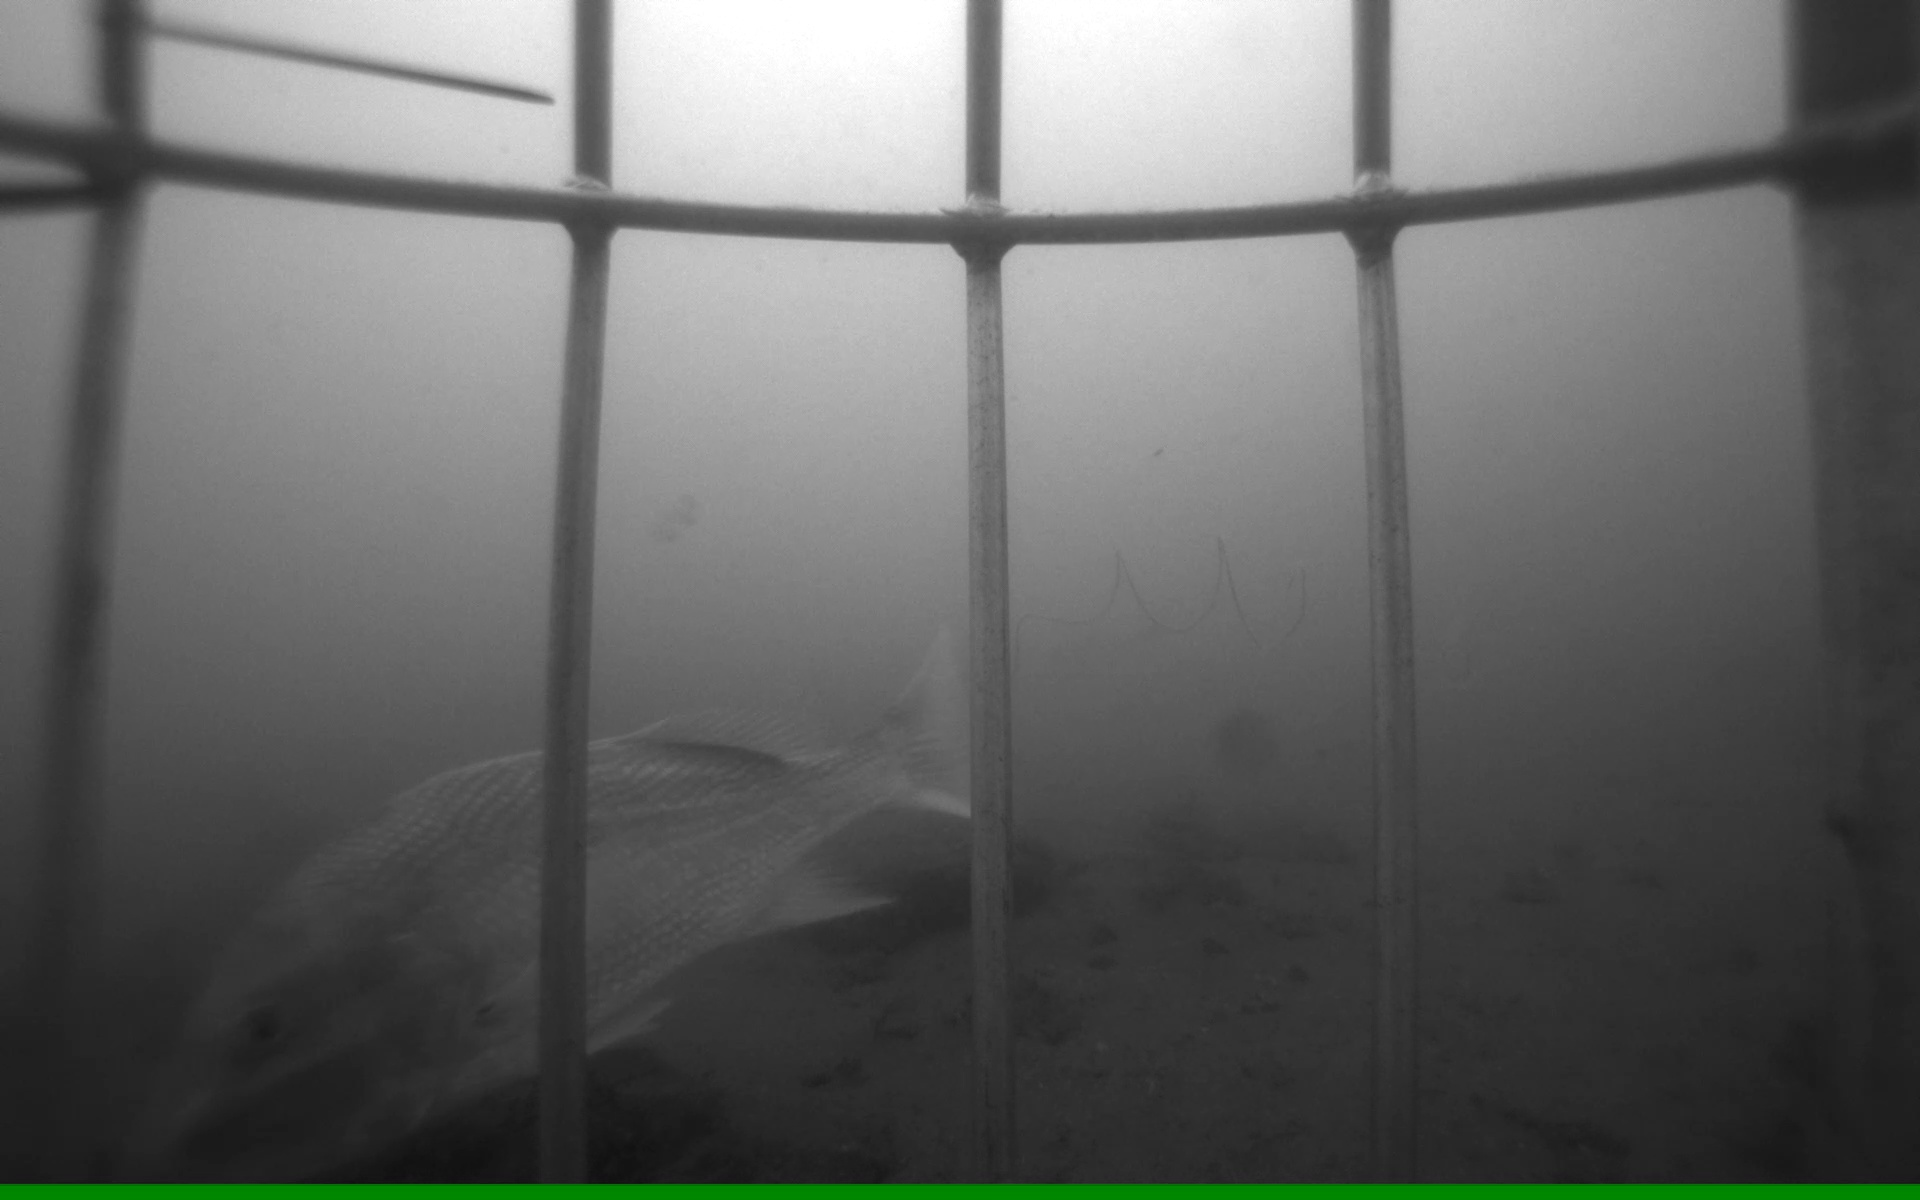

In [10]:
image = Image.open(arbitrary_image).convert('RGB')
image

In [12]:
def postprocess_raw_output(
    raw_yolo_output: torch.Tensor,
    nms_iou_thres: float | None = None,
    nms_conf_thres: float | None = None,
) -> tuple[list[torch.Tensor], list[torch.Tensor]]:
    """Applies Non-Max Suppression (NMS) to raw YOLO output.

    This function passes the `classes=roots` argument to the Ultralytics
    `non_max_suppression` function. This internally filters detections
    by finding the single highest-scoring class for each box, and then
    keeping only those boxes where that single highest-scoring class
    is one of the `roots`.

    It then separates the boxes and the full class score vectors for the
    surviving detections.

    .. todo::
       The current logic is flawed for hierarchical models. `non_max_suppression`
       finds the `argmax` over *all* classes, and only THEN does the `classes`
       argument do anything. But, for hierarchical conditional
       probabilities, the single max score is not meaningful. The intended
       logic (to be fixed in a future branch) is to run NMS *only* on the
       subset of root class scores, not to filter by the global argmax.

    Parameters
    ----------
    raw_yolo_output : torch.Tensor
        The raw output tensor from the YOLO model, expected in
        `(B, C+4, N)` format, where B=batch, C=classes, N=proposals.
    nms_iou_thres : float, optional
        IoU threshold for NMS. By default 0.7.
    nms_conf_thres : float, optional
        Confidence threshold for NMS. By default 0.25.

    Returns
    -------
    tuple[list[torch.Tensor], list[torch.Tensor]]
        A tuple containing two lists, one for boxes and one for scores,
        with one entry per batch item:
        1. `all_boxes`: List[torch.Tensor], where each tensor is shape
           `(4, N_filtered)` containing bounding boxes.
        2. `all_class_scores`: List[torch.Tensor], where each tensor is
           shape `(C, N_filtered)` containing all class scores for the
           surviving boxes.
    """
    try:
        from ultralytics.utils.ops import non_max_suppression # old version
    except:
        from ultralytics.utils.nms import non_max_suppression # new version

    nms_iou_thres = nms_iou_thres or 0.7
    nms_conf_thres = nms_conf_thres or 0.25
    all_boxes = []
    all_class_scores = []
    _, nms_idxs = non_max_suppression(raw_yolo_output, return_idxs=True, iou_thres=nms_iou_thres, conf_thres=nms_conf_thres)
    for i, idx in enumerate(nms_idxs):
        flat_idx = idx.flatten().long()
        nms_output = raw_yolo_output[i].index_select(1, flat_idx)
        boxes = nms_output[:4, :]
        class_scores = nms_output[4:, :]
        all_boxes.append(boxes)
        all_class_scores.append(class_scores)
    return all_boxes, all_class_scores

In [13]:
BATCH_SIZE = 20
val_boxes, val_preds = [], [] 
for i, batch in enumerate(itertools.batched(images_path, BATCH_SIZE)):
    images = [Image.open(img).convert('RGB') for img in batch]
    raw_predictions = hierarchical_yolo.yolo_utils.yolo_raw_predict(trained_model, images, (640, 640))
    boxes_tensor, scores_tensor = postprocess_raw_output(raw_predictions)
    val_boxes.append(boxes_tensor)
    val_preds.append(scores_tensor)

In [14]:
val_preds[0][0].T.shape

torch.Size([1, 260])

In [15]:
BIOTA = 26

In [16]:
with open(YOLO_DATASET_YAML, 'r') as f:
    cats = yaml.safe_load(f.read())['names']

In [17]:
cats

{0: 'Acanthuriformes',
 1: 'Actinopteri',
 2: 'Actinopterygii',
 3: 'Albula',
 4: 'Albula vulpes',
 5: 'Albulidae',
 6: 'Albuliformes',
 7: 'Albulinae',
 8: 'Alectis',
 9: 'Alectis ciliaris',
 10: 'Anguilliformes',
 11: 'Animalia',
 12: 'Anisotremus',
 13: 'Anisotremus virginicus',
 14: 'Anomura',
 15: 'Anthiadidae',
 16: 'Archosargus',
 17: 'Archosargus probatocephalus',
 18: 'Arthropoda',
 19: 'Aulopiformes',
 20: 'Aulopoidei',
 21: 'Balistes',
 22: 'Balistes capriscus',
 23: 'Balistes vetula',
 24: 'Balistidae',
 25: 'Balistoidei',
 26: 'Biota',
 27: 'Bodianus',
 28: 'Bodianus pulchellus',
 29: 'Bodianus rufus',
 30: 'Brachyura',
 31: 'Calamus',
 32: 'Calamus bajonado',
 33: 'Calamus leucosteus',
 34: 'Calamus nodosus',
 35: 'Calamus proridens',
 36: 'Callionymidae',
 37: 'Callionymiformes',
 38: 'Canthidermis',
 39: 'Canthidermis sufflamen',
 40: 'Canthigaster',
 41: 'Canthigaster jamestyleri',
 42: 'Canthigaster rostrata',
 43: 'Carangaria incertae sedis',
 44: 'Carangidae',
 45: 

In [32]:
PUBLIC_COCO_URL_ROOT = 'https://storage.googleapis.com/nmfs_odp_hq/nodd_tools/datasets/gfisher/'

categories = [
    {
        'name': name,
        'id': i
    } for i, name in cats.items()
]
images = []
for i, filename in enumerate(image_filenames):
    station = filename.split('.avi')
    if len(station) < 2:
        station = filename.split('.mp4')
    station = station[0]
    width, height = Image.open(os.path.join(IMAGES_PATH, filename)).size
    images.append(
        {
            'id': i,
            'file_name': filename,
            'coco_url': PUBLIC_COCO_URL_ROOT + station + '/' + filename,
            'width': width,
            'height': height
        }
    )
annotations = []
img_idx = 0
ann_idx = 0
for pred_batch, box_batch in zip(val_preds, val_boxes):
    for preds, boxes in zip(pred_batch, box_batch):
        img_w = images[img_idx]['width']
        img_h = images[img_idx]['height']
        scale_w = img_w/640
        scale_h = img_h/640
        for pred, box in zip(preds.T, boxes.T):
            annotations.append( 
                {
                    'id': ann_idx,
                    'image_id': img_idx,
                    'bbox': [
                        int(box[0] * scale_w),
                        int(box[1] * scale_h),
                        int((box[2] - box[0])*scale_w),
                        int((box[3] - box[1])*scale_h)
                    ],
                    'category_id': pred.argmax().item(),
                    'scores': [f'{x.item():.5f}' for x in pred]
                }
            )
            annotations[-1]['area'] = annotations[-1]['bbox'][-1] * annotations[-1]['bbox'][-2]
            ann_idx += 1
        img_idx += 1
            
new_coco = {
    'images': images,
    'annotations': annotations,
    'categories': categories
}

In [33]:
len(new_coco['images'])

1003

In [34]:
len(annotations)

1934

In [35]:
(
    new_coco['images'][0],
    new_coco['annotations'][0],
    new_coco['categories'][0]
)

({'id': 0,
  'file_name': '2021_NCD-047b.mp4.00.00.00.000000.jpg',
  'coco_url': 'https://storage.googleapis.com/nmfs_odp_hq/nodd_tools/datasets/gfisher/2021_NCD-047b/2021_NCD-047b.mp4.00.00.00.000000.jpg',
  'width': 1920,
  'height': 1200},
 {'id': 0,
  'image_id': 0,
  'bbox': [1765, 539, 131, 63],
  'category_id': 164,
  'scores': ['0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00002',
   '0.00000',
   '0.00000',
   '0.00001',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00621',
   '0.00011',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00544',
   '0.00000',
   '0.00001',
   '0.00002',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00003',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.0

In [36]:
import json
with open('gfisher_preds_' + str(max(model_numbers)) + '.json','w') as f:
    json.dump(new_coco, f)